<h1 style="
    background-color:#D9EAF7;
    color:#17365D;
    font-family:'Times New Roman';
    font-weight:bold;
    text-align:center;
    padding:15px;
    border:2px solid #17365D;
">
INDIAN CYBERSECURITY &amp; CERT-IN INCIDENT ANALYSIS
</h1>

<h2 style="
    background-color:#EAF2F8;
    color:#17365D;
    font-family:'Times New Roman';
    font-weight:bold;
    padding:10px;
    border-left:5px solid #17365D;
">
Python Analysis
</h2>

<h3 style="
    background-color:#F4F6F7;
    color:#17365D;
    font-family:'Times New Roman';
    font-weight:bold;
    padding:8px;
">
1. Data Preparation
</h3>

In [1]:
import pandas as pd

In [2]:
yearly_incidents = pd.DataFrame({
    "Year": [2020, 2021, 2022, 2023, 2024],
    "Number_of_Incidents": [1158208, 1402809, 1391457, 1592917, 2041360]
})

yearly_incidents

,Year,Number_of_Incidents
0,2020,1158208
1,2021,1402809
2,2022,1391457
3,2023,1592917
4,2024,2041360


In [3]:
yearly_incidents.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Year                 5 non-null      int64
 1   Number_of_Incidents  5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes


In [4]:
yearly_incidents.describe()

,Year,Number_of_Incidents
count,5.000000,5.000000e+00
mean,2022.000000,1.517350e+06
std,1.581139,3.310017e+05
min,2020.000000,1.158208e+06
25%,2021.000000,1.391457e+06
50%,2022.000000,1.402809e+06
75%,2023.000000,1.592917e+06
max,2024.000000,2.041360e+06


In [5]:
yearly_incidents.isnull().sum()

Year                   0
Number_of_Incidents    0
dtype: int64

In [6]:
yearly_incidents.duplicated().sum()

np.int64(0)

<h3 style="
    background-color:#F4F6F7;
    color:#17365D;
    font-family:'Times New Roman';
    font-weight:bold;
    padding:8px;
">
2. Incident Type Analysis
</h3>

In [7]:
incident_types = pd.DataFrame({
    "Incident_Type": [
        "Phishing",
        "Unauthorized Network Scanning / Probing",
        "Vulnerable Services",
        "Virus / Malicious Code",
        "Website Defacements",
        "Website Intrusion & Malware Propagation",
        "Others"
    ],
    "Incidents": [
        785,
        1610608,
        294908,
        119763,
        5496,
        1246,
        8554
    ]
})

incident_types

,Incident_Type,Incidents
0,Phishing,785
1,Unauthorized Network Scanning / Probing,1610608
2,Vulnerable Services,294908
3,Virus / Malicious Code,119763
4,Website Defacements,5496
5,Website Intrusion & Malware Propagation,1246
6,Others,8554


In [8]:
incident_types.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Incident_Type  7 non-null      str  
 1   Incidents      7 non-null      int64
dtypes: int64(1), str(1)
memory usage: 244.0 bytes


In [9]:
incident_types.describe()

,Incidents
count,7.000000e+00
mean,2.916229e+05
std,5.916320e+05
min,7.850000e+02
25%,3.371000e+03
50%,8.554000e+03
75%,2.073355e+05
max,1.610608e+06


In [10]:
incident_types.isnull().sum()

Incident_Type    0
Incidents        0
dtype: int64

In [11]:
incident_types.duplicated().sum()

np.int64(0)

In [12]:
total_incidents = incident_types["Incidents"].sum()

print("Total Incidents:", total_incidents)

Total Incidents: 2041360


In [13]:
incident_types["Percentage_of_Total"] = (
    incident_types["Incidents"] / total_incidents * 100
).round(2)

incident_types

,Incident_Type,Incidents,Percentage_of_Total
0,Phishing,785,0.04
1,Unauthorized Network Scanning / Probing,1610608,78.90
2,Vulnerable Services,294908,14.45
3,Virus / Malicious Code,119763,5.87
4,Website Defacements,5496,0.27
5,Website Intrusion & Malware Propagation,1246,0.06
6,Others,8554,0.42


In [14]:
incident_types_sorted = incident_types.sort_values(
    by="Incidents",
    ascending=False
)

incident_types_sorted

,Incident_Type,Incidents,Percentage_of_Total
1,Unauthorized Network Scanning / Probing,1610608,78.90
2,Vulnerable Services,294908,14.45
3,Virus / Malicious Code,119763,5.87
6,Others,8554,0.42
4,Website Defacements,5496,0.27
5,Website Intrusion & Malware Propagation,1246,0.06
0,Phishing,785,0.04


In [15]:
top_3_incidents = incident_types_sorted.head(3)

top_3_incidents

,Incident_Type,Incidents,Percentage_of_Total
1,Unauthorized Network Scanning / Probing,1610608,78.90
2,Vulnerable Services,294908,14.45
3,Virus / Malicious Code,119763,5.87


In [16]:
yearly_incidents["Previous_Year_Incidents"] = (
    yearly_incidents["Number_of_Incidents"].shift(1)
)

yearly_incidents["YoY_Growth_Percent"] = (
    yearly_incidents["Number_of_Incidents"]
    .pct_change()
    .mul(100)
    .round(2)
)

yearly_incidents

,Year,Number_of_Incidents,Previous_Year_Incidents,YoY_Growth_Percent
0,2020,1158208,NaN,NaN
1,2021,1402809,1158208.0,21.12
2,2022,1391457,1402809.0,-0.81
3,2023,1592917,1391457.0,14.48
4,2024,2041360,1592917.0,28.15


In [17]:
highest_growth_year = yearly_incidents.loc[
    yearly_incidents["YoY_Growth_Percent"].idxmax()
]

highest_growth_year

Year                          2024.00
Number_of_Incidents        2041360.00
Previous_Year_Incidents    1592917.00
YoY_Growth_Percent              28.15
Name: 4, dtype: float64

In [18]:
average_annual_incidents = yearly_incidents["Number_of_Incidents"].mean()

print("Average Annual Incidents:", round(average_annual_incidents, 2))

Average Annual Incidents: 1517350.2


In [19]:
yearly_incidents["Above_Average"] = (
    yearly_incidents["Number_of_Incidents"]
    > average_annual_incidents
)

yearly_incidents

,Year,Number_of_Incidents,Previous_Year_Incidents,YoY_Growth_Percent,Above_Average
0,2020,1158208,NaN,NaN,False
1,2021,1402809,1158208.0,21.12,False
2,2022,1391457,1402809.0,-0.81,False
3,2023,1592917,1391457.0,14.48,True
4,2024,2041360,1592917.0,28.15,True


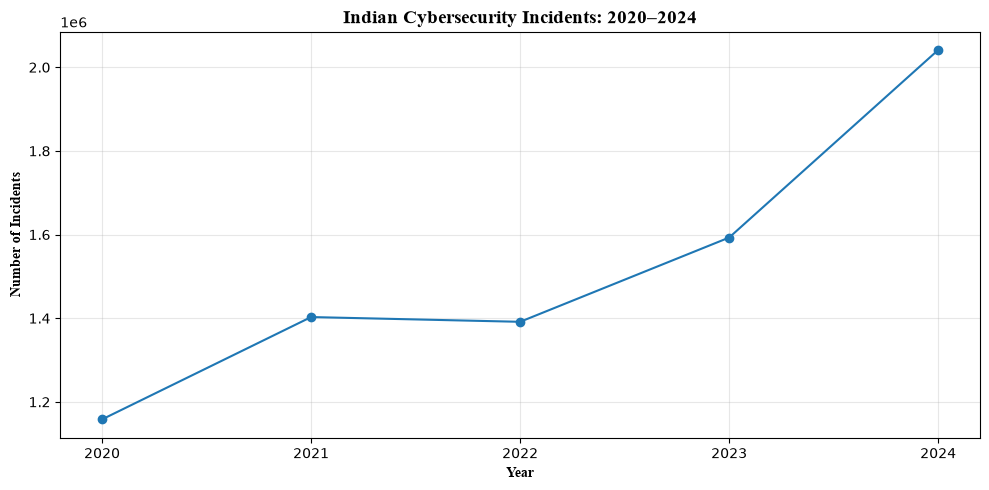

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_incidents["Year"],
    yearly_incidents["Number_of_Incidents"],
    marker="o"
)

plt.title(
    "Indian Cybersecurity Incidents: 2020–2024",
    fontname="Times New Roman",
    fontweight="bold",
    fontsize=14
)

plt.xlabel("Year", fontname="Times New Roman", fontweight="bold")
plt.ylabel("Number of Incidents", fontname="Times New Roman", fontweight="bold")

plt.xticks(yearly_incidents["Year"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

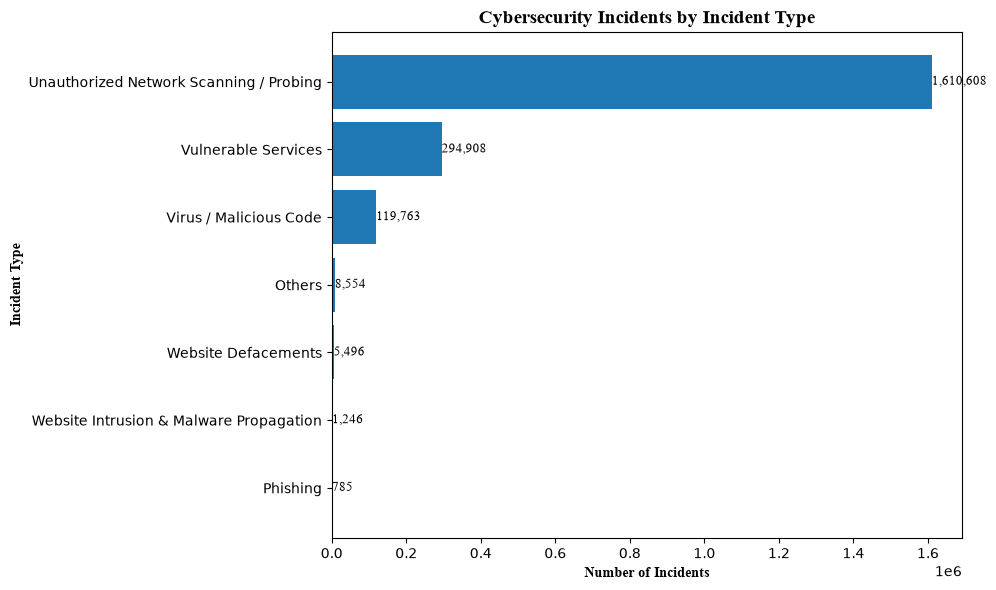

In [22]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    incident_types_sorted["Incident_Type"],
    incident_types_sorted["Incidents"]
)

plt.title(
    "Cybersecurity Incidents by Incident Type",
    fontname="Times New Roman",
    fontweight="bold",
    fontsize=14
)

plt.xlabel(
    "Number of Incidents",
    fontname="Times New Roman",
    fontweight="bold"
)

plt.ylabel(
    "Incident Type",
    fontname="Times New Roman",
    fontweight="bold"
)

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        ha="left",
        fontname="Times New Roman",
        fontsize=9
    )

plt.tight_layout()
plt.show()

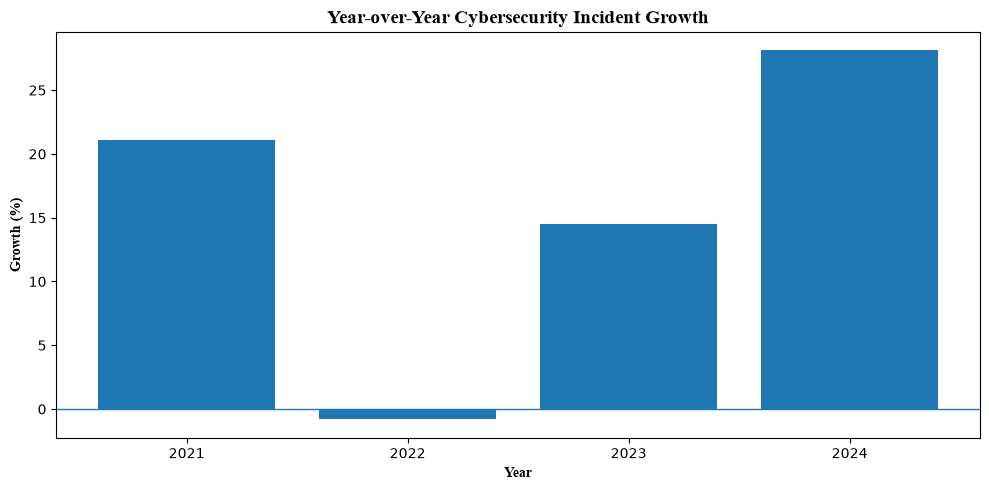

In [26]:
plt.figure(figsize=(10, 5))

plt.bar(
    yearly_incidents["Year"].astype(str),
    yearly_incidents["YoY_Growth_Percent"]
)

plt.title(
    "Year-over-Year Cybersecurity Incident Growth",
    fontname="Times New Roman",
    fontweight="bold",
    fontsize=14
)

plt.xlabel("Year", fontname="Times New Roman", fontweight="bold")
plt.ylabel("Growth (%)", fontname="Times New Roman", fontweight="bold")

plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

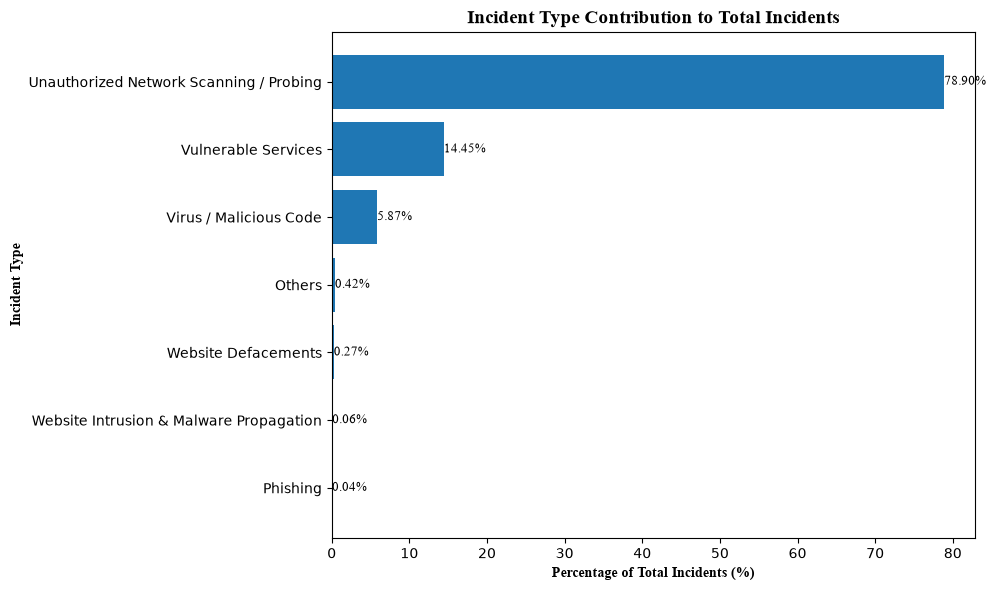

In [27]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    incident_types_sorted["Incident_Type"],
    incident_types_sorted["Percentage_of_Total"]
)

plt.title(
    "Incident Type Contribution to Total Incidents",
    fontname="Times New Roman",
    fontweight="bold",
    fontsize=14
)

plt.xlabel(
    "Percentage of Total Incidents (%)",
    fontname="Times New Roman",
    fontweight="bold"
)

plt.ylabel(
    "Incident Type",
    fontname="Times New Roman",
    fontweight="bold"
)

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center",
        ha="left",
        fontname="Times New Roman",
        fontsize=9
    )

plt.tight_layout()
plt.show()

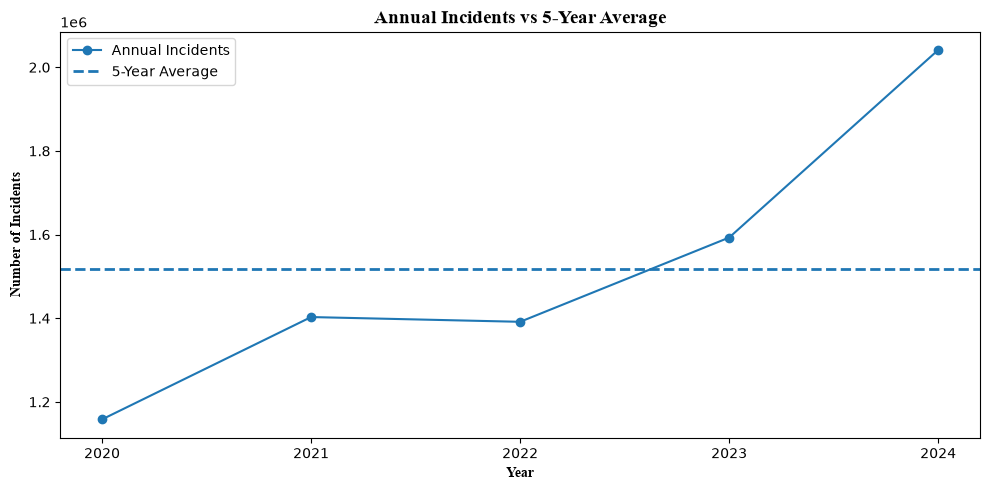

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_incidents["Year"],
    yearly_incidents["Number_of_Incidents"],
    marker="o",
    label="Annual Incidents"
)

plt.axhline(
    average_annual_incidents,
    linestyle="--",
    linewidth=2,
    label="5-Year Average"
)

plt.title(
    "Annual Incidents vs 5-Year Average",
    fontname="Times New Roman",
    fontweight="bold",
    fontsize=14
)

plt.xlabel(
    "Year",
    fontname="Times New Roman",
    fontweight="bold"
)

plt.ylabel(
    "Number of Incidents",
    fontname="Times New Roman",
    fontweight="bold"
)

plt.xticks(yearly_incidents["Year"])
plt.legend()

plt.tight_layout()
plt.show()

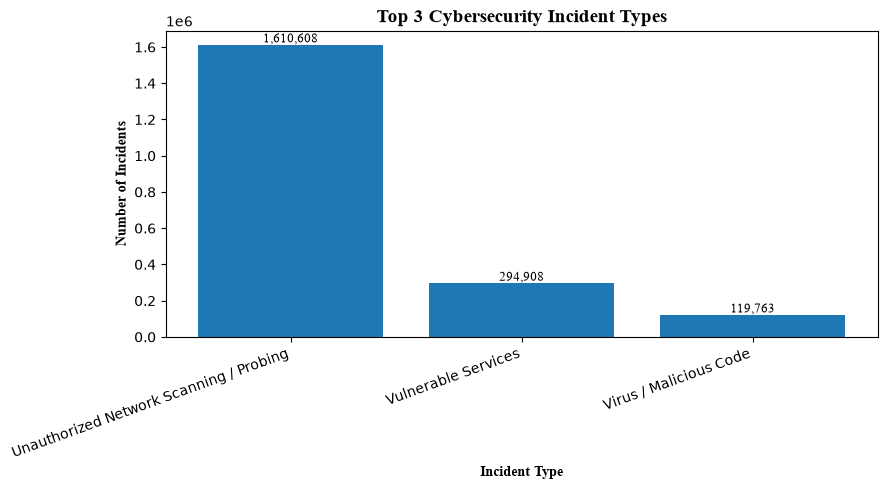

In [29]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    top_3_incidents["Incident_Type"],
    top_3_incidents["Incidents"]
)

plt.title(
    "Top 3 Cybersecurity Incident Types",
    fontname="Times New Roman",
    fontweight="bold",
    fontsize=14
)

plt.xlabel(
    "Incident Type",
    fontname="Times New Roman",
    fontweight="bold"
)

plt.ylabel(
    "Number of Incidents",
    fontname="Times New Roman",
    fontweight="bold"
)

plt.xticks(rotation=20, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontname="Times New Roman",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [30]:
incident_types_sorted["Cumulative_Percentage"] = (
    incident_types_sorted["Percentage_of_Total"].cumsum()
).round(2)

incident_types_sorted

,Incident_Type,Incidents,Percentage_of_Total,Cumulative_Percentage
1,Unauthorized Network Scanning / Probing,1610608,78.90,78.90
2,Vulnerable Services,294908,14.45,93.35
3,Virus / Malicious Code,119763,5.87,99.22
6,Others,8554,0.42,99.64
4,Website Defacements,5496,0.27,99.91
5,Website Intrusion & Malware Propagation,1246,0.06,99.97
0,Phishing,785,0.04,100.01


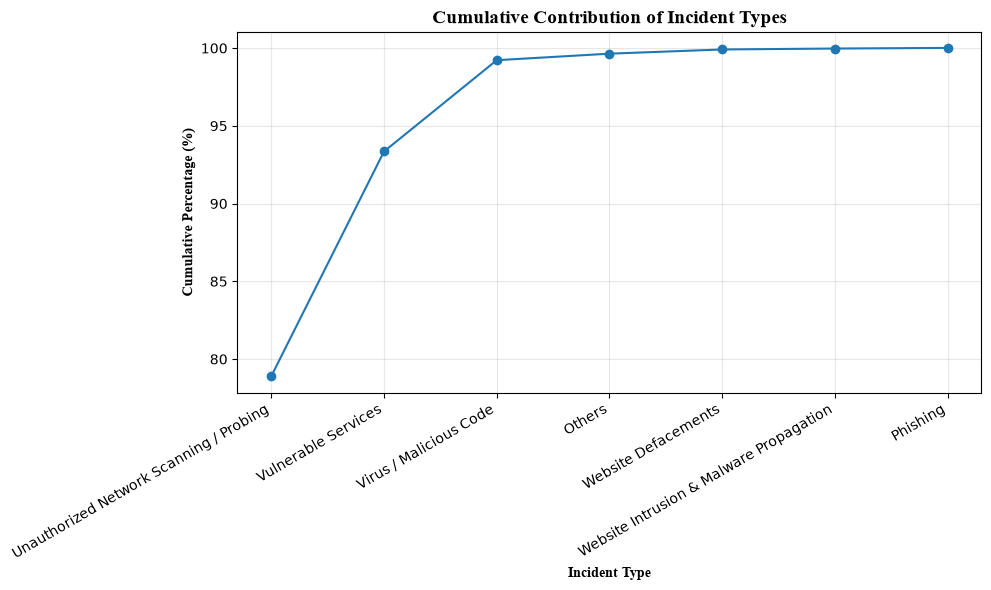

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    incident_types_sorted["Incident_Type"],
    incident_types_sorted["Cumulative_Percentage"],
    marker="o"
)

plt.title(
    "Cumulative Contribution of Incident Types",
    fontname="Times New Roman",
    fontweight="bold",
    fontsize=14
)

plt.xlabel(
    "Incident Type",
    fontname="Times New Roman",
    fontweight="bold"
)

plt.ylabel(
    "Cumulative Percentage (%)",
    fontname="Times New Roman",
    fontweight="bold"
)

plt.xticks(rotation=30, ha="right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
start_incidents = yearly_incidents.loc[
    yearly_incidents["Year"] == 2020, "Number_of_Incidents"
].iloc[0]

end_incidents = yearly_incidents.loc[
    yearly_incidents["Year"] == 2024, "Number_of_Incidents"
].iloc[0]

total_increase = end_incidents - start_incidents

growth_percent = (total_increase / start_incidents * 100).round(2)

print("2020 Incidents:", start_incidents)
print("2024 Incidents:", end_incidents)
print("Total Increase:", total_increase)
print("Overall Growth:", growth_percent, "%")

2020 Incidents: 1158208
2024 Incidents: 2041360
Total Increase: 883152
Overall Growth: 76.25 %


In [24]:
percentage_total = incident_types["Percentage_of_Total"].sum()

print("Total Percentage:", percentage_total, "%")

Total Percentage: 100.01000000000002 %


In [25]:
incident_types[[
    "Incident_Type",
    "Incidents",
    "Percentage_of_Total"
]]

,Incident_Type,Incidents,Percentage_of_Total
0,Phishing,785,0.04
1,Unauthorized Network Scanning / Probing,1610608,78.90
2,Vulnerable Services,294908,14.45
3,Virus / Malicious Code,119763,5.87
4,Website Defacements,5496,0.27
5,Website Intrusion & Malware Propagation,1246,0.06
6,Others,8554,0.42


<h3 style="
    background-color:#F4F6F7;
    color:#17365D;
    font-family:'Times New Roman';
    font-weight:bold;
    padding:8px;
">
3. Consolidated Insights
</h3>

### Key Insights

- Cybersecurity incidents handled by CERT-In increased from **1,158,208 in 2020 to 2,041,360 in 2024**, representing an overall increase of **76.25%**.
- The highest year-over-year growth occurred in **2024**, with incidents increasing by **28.15%** compared with 2023.
- **2022** was the only year in the period that recorded a slight decline, with incidents decreasing by **0.81%** from 2021.
- **Unauthorized Network Scanning / Probing** was the dominant incident category, accounting for approximately **78.91%** of incidents reported in 2024.
- **Vulnerable Services** contributed approximately **14.45%**, while **Virus / Malicious Code** contributed approximately **5.87%**.
- The top two incident categories together accounted for approximately **93.35%** of all incidents, showing a highly concentrated incident distribution.
- Only **2023 and 2024** recorded incident volumes above the five-year average of approximately **1.52 million incidents per year**.
- The analysis indicates a strong upward trend in cybersecurity incidents, with particularly rapid growth in the most recent year of the dataset.

### Conclusion

The analysis shows a substantial increase in cybersecurity incidents handled by CERT-In between 2020 and 2024. The incident distribution is heavily concentrated in a small number of categories, particularly Unauthorized Network Scanning / Probing and Vulnerable Services. The strong increase in 2024 highlights the growing scale of cybersecurity activity and the importance of continuous monitoring and security preparedness.

<h2 style="
    background-color:#EAF2F8;
    color:#17365D;
    font-family:'Times New Roman';
    font-weight:bold;
    padding:10px;
    border-left:5px solid #17365D;
">
Final Project Insights
</h2>

### Overall Findings

- CERT-In handled **7,586,751 cybersecurity incidents** across the 2020–2024 period.
- The annual incident volume increased from **1,158,208 in 2020 to 2,041,360 in 2024**, representing a **76.25% overall increase**.
- **2024 recorded the highest incident volume** and the highest year-over-year growth, at **28.15%**.
- **2022** showed a slight year-over-year decline of **0.81%**, before incident volumes increased again in 2023 and 2024.
- In 2024, **Unauthorized Network Scanning / Probing** represented approximately **78.91%** of all incidents.
- **Vulnerable Services** accounted for approximately **14.45%**, while **Virus / Malicious Code** accounted for approximately **5.87%**.
- The two largest incident categories together represented approximately **93.35%** of the 2024 incident total, indicating a highly concentrated distribution.
- The five-year average was approximately **1.52 million incidents per year**, with 2023 and 2024 exceeding this average.
- SQL and Python analysis produced consistent totals, while the Power BI dashboard provides an interactive way to explore the yearly and incident-type patterns.

### Business Interpretation

The analysis highlights the increasing scale of cybersecurity incidents reported to CERT-In during 2020–2024. The concentration of incidents in a small number of categories provides useful context for understanding the major areas represented in the reported incident data. The sharp increase in 2024 also indicates that recent cybersecurity activity reached its highest recorded level within the analyzed period.

### Analytical Outcome

This project demonstrates an end-to-end data analytics workflow using **Excel, SQL, Python, and Power BI**, covering data validation, analytical querying, exploratory analysis, visualization, and dashboard development.